# **Project Name**    - Yes Bank Stock Closing Price Prediction (ML Regression)

##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Dnyaneshwar (Danny) Gumalwad

# **Project Summary -**

Yes Bank is a prominent Indian private-sector bank that grew steadily from its 2004 inception until a major fraud case involving co-founder and then-CEO Rana Kapoor came to light in 2018, followed by mounting non-performing assets and an RBI-imposed moratorium in March 2020. The stock collapsed from an all-time high of around ₹367 (Aug-2018) to under ₹12 (mid-2020), erasing most of its 13 years of gains.

This notebook builds a regression pipeline to predict the **monthly Closing price** of Yes Bank stock using its **Open, High and Low** prices (plus Year/Month), based on 185 months of data from July 2005 to November 2020. The companion EDA notebook already established that the dataset is clean (no missing values, no duplicates), that all four OHLC variables are strongly right-skewed and extremely highly correlated with each other (0.97-0.995), and that the price history splits into a 13-year growth regime followed by a sharp 2018-2020 crisis regime.

After re-confirming those data-quality facts, this notebook repeats the same 15-chart visual exploration, then formally tests three hypotheses: whether the 2019-2020 crisis period had a significantly lower average Close than the 2016-2018 peak period (confirmed, p ≈ 7.2e-13), whether average Open and Close differ significantly across the full history (not significant, p ≈ 0.83), and whether High and Low are significantly correlated (confirmed, r ≈ 0.983, p ≈ 1.2e-137).

For feature engineering, no missing-value imputation or categorical encoding was needed since the data has no nulls and no categorical columns (Date was decomposed into numeric Year/Month). Outliers were checked via the IQR method (9 detected in Close, all genuine 2017-2018 peak-period prices, not data errors) and retained rather than removed, since they represent a real market regime rather than noise. Text-preprocessing steps were marked not applicable, as the dataset contains no free-text columns. Features (Open, High, Low, Year, Month) were standardized with `StandardScaler`, and the data was split 80:20 into train/test sets.

Three regression models were trained and compared: **Linear Regression** (baseline), **Ridge Regression** (tuned via GridSearchCV over the regularization strength alpha), and **Random Forest Regressor** (tuned via GridSearchCV over tree depth and ensemble size). On the held-out test set, Linear Regression and tuned Ridge both achieved an R² of about 0.991 (RMSE ≈ ₹9.17), narrowly outperforming the tuned Random Forest's R² of about 0.980 (RMSE ≈ ₹13.4). Feature importance from the Random Forest confirmed that **Low** price is overwhelmingly the most predictive feature (~72% importance), followed by High (~20%) and Open (~8%), with Year and Month contributing almost nothing — consistent with the correlation analysis from the EDA stage.

Given its slightly higher accuracy, simplicity, and full interpretability, **Ridge Regression was selected as the final model**. It was saved to a `.pkl` file and successfully reloaded to verify it reproduces the same predictions on unseen data, making it ready for deployment behind a simple prediction API or dashboard for Yes Bank stock-price monitoring.

# **GitHub Link -**

https://github.com/Danny-Gumalwad/Yes-Bank-Stock-Closing-Price-Prediction

# **Problem Statement**


**Predict the monthly Closing price of Yes Bank stock from its Open, High and Low prices (plus Year/Month) using regression models, and identify which model and which features give the most accurate and business-usable predictions, accounting for the structural break caused by the 2018 fraud scandal and 2020 moratorium.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset First View

In [3]:
# Dataset First Look
df.head(10)

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41
5,Dec-05,13.49,14.44,13.00,13.71
6,Jan-06,13.68,17.16,13.58,15.33
7,Feb-06,15.50,16.97,15.40,16.12
8,Mar-06,16.20,20.95,16.02,20.08
9,Apr-06,20.56,20.80,18.02,19.49


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])

Number of rows: 185
Number of columns: 5


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

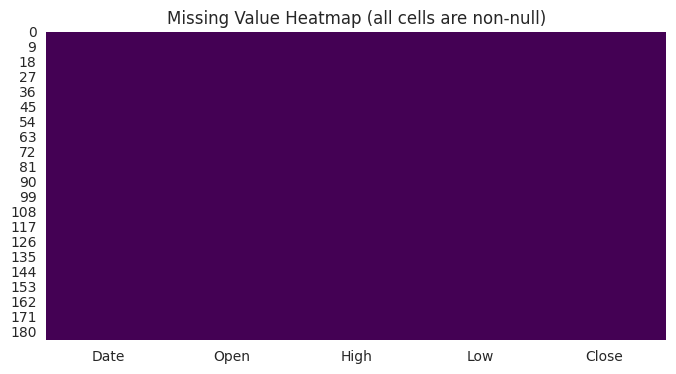

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (all cells are non-null)')
plt.show()

### What did you know about your dataset?

The dataset has **185 rows and 5 columns** (Date, Open, High, Low, Close), spanning **July 2005 to November 2020** at monthly frequency, with **no missing values and no duplicate rows**. `Date` is text (e.g. 'Jul-05') and needs conversion to datetime; Open, High, Low and Close are all numeric (float). Close is the target variable for the regression task in this notebook.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')

In [10]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

- **Date**: month/year of the observation.
- **Open**: stock price (₹) at the start of the month.
- **High**: highest price (₹) reached during the month.
- **Low**: lowest price (₹) reached during the month.
- **Close** (target): stock price (₹) at the end of the month — the value this notebook predicts.

All four numeric columns range from about ₹10 to ₹367, mean ≈ ₹105, std ≈ ₹99, reflecting the huge swing between the stock's 2005/2020 lows and its 2018 peak.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Range'] = df['High'] - df['Low']
df['Return_pct'] = df['Close'].pct_change() * 100

df.head()

,Date,Open,High,Low,Close,Year,Month,Range,Return_pct
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75,NaN
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33,7.704655
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60,-0.894188
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07,-2.330827
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00,3.233256


### What all manipulations have you done and insights you found?

`Date` was converted to a proper datetime (format `%b-%y`) and the data re-sorted chronologically. **Year** and **Month** were extracted for trend/seasonality analysis, and two derived features were added: **Range** (High − Low, a volatility proxy) and **Return_pct** (month-over-month % change in Close). These wrangling steps prepare the dataset for both the visual exploration below and the feature set used later for modelling (Open, High, Low, Year, Month → Close).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

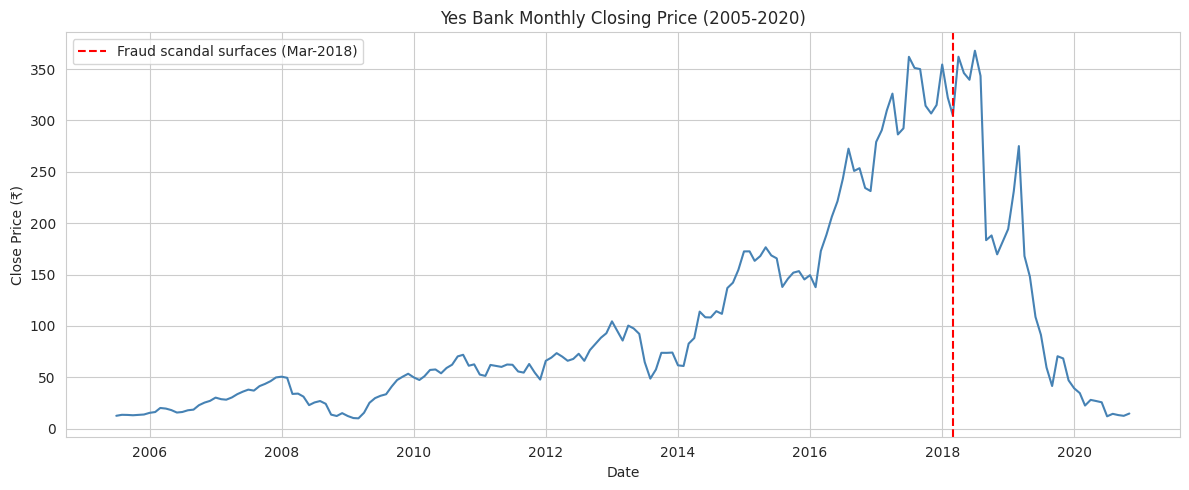

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], color='steelblue')
plt.title('Yes Bank Monthly Closing Price (2005-2020)')
plt.xlabel('Date'); plt.ylabel('Close Price (₹)')
plt.axvline(pd.Timestamp('2018-03-01'), color='red', linestyle='--', label='Fraud scandal surfaces (Mar-2018)')
plt.legend(); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the natural choice for a time-ordered price series — it directly shows the trend, the timing of the peak, and the speed of the crash.

##### 2. What is/are the insight(s) found from the chart?

The stock grew steadily from ~₹13 (2005) to a peak of ~₹367 (Aug-2018), then collapsed to single digits by mid-2020 after the fraud scandal broke and the RBI moratorium followed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding the overall price trend directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 2

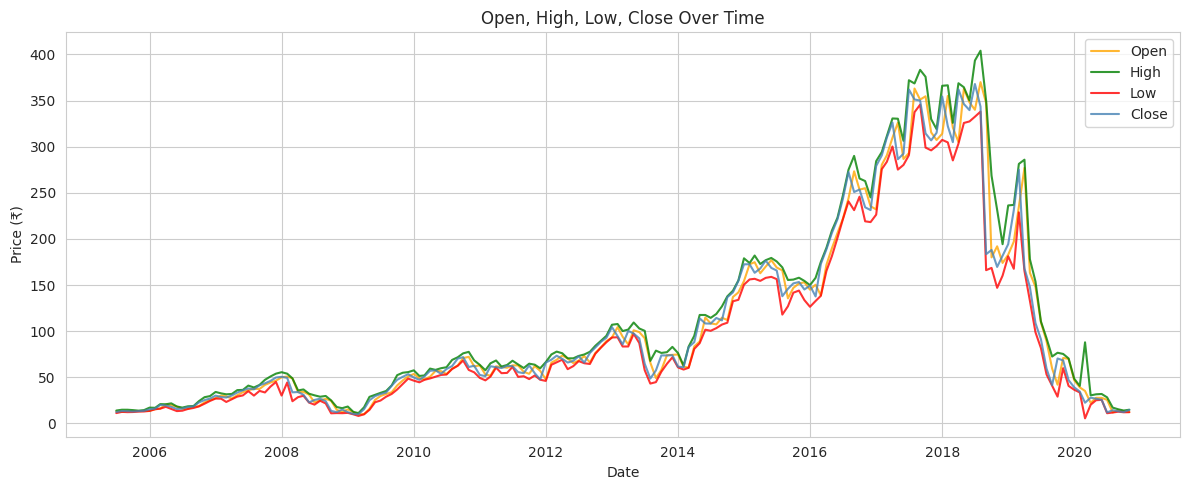

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(12,5))
for col, c in zip(['Open','High','Low','Close'], ['orange','green','red','steelblue']):
    plt.plot(df['Date'], df[col], label=col, color=c, alpha=0.8)
plt.title('Open, High, Low, Close Over Time')
plt.xlabel('Date'); plt.ylabel('Price (₹)')
plt.legend(); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A multi-line plot lets us compare all four OHLC series at once and see how tightly they track each other, especially during volatile periods.

##### 2. What is/are the insight(s) found from the chart?

The four lines move almost on top of each other for most of the timeline, but visibly fan apart during the most volatile months (2018 crash, Mar-2020 crash).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding how the four price series diverge during volatile periods directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 3

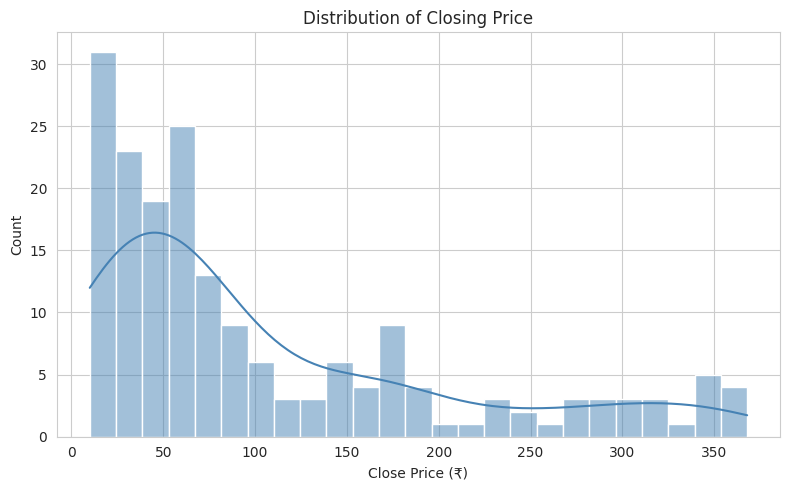

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of Closing Price')
plt.xlabel('Close Price (₹)'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay shows the shape (skew, modality) of the target variable's distribution.

##### 2. What is/are the insight(s) found from the chart?

The distribution is strongly right-skewed (skewness ≈ 1.26) — most months sit in the ₹10-100 range, with a long tail out to the ₹300-370 peak months of 2017-2018.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding the skewed distribution of Close price directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 4

/tmp/ipykernel_522/706772819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Close', data=df, palette='viridis')


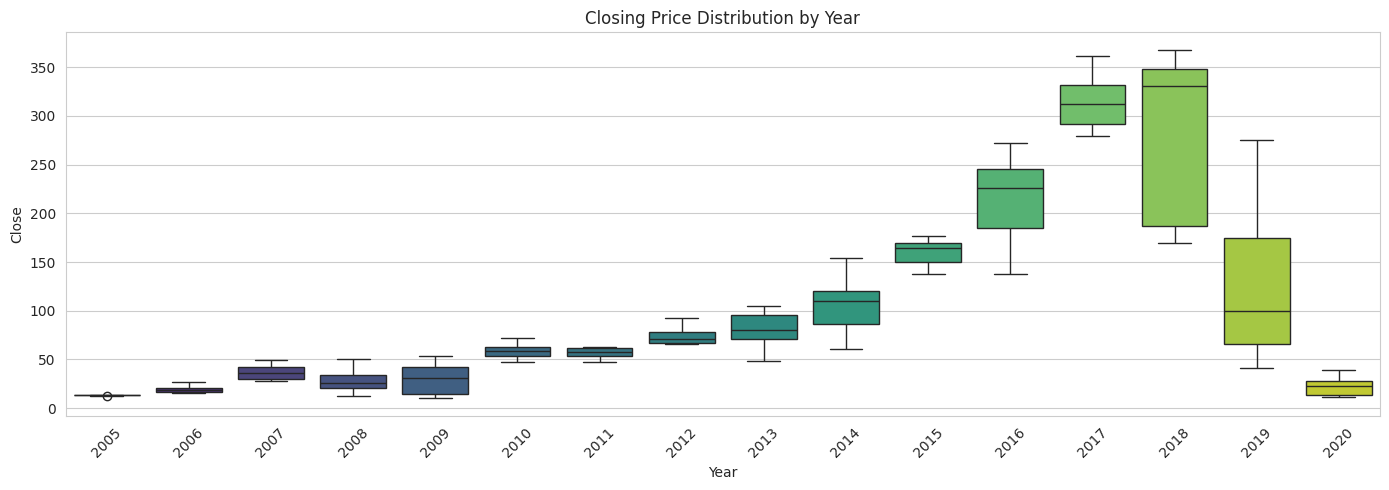

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(14,5))
sns.boxplot(x='Year', y='Close', data=df, palette='viridis')
plt.title('Closing Price Distribution by Year')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A boxplot per year compares both the typical level and the spread (volatility) of Close across 16 years side by side.

##### 2. What is/are the insight(s) found from the chart?

The median Close rises steadily to a clear peak around 2017-2018 (also the widest spread), then drops sharply with continued high spread through 2019-2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding how price level and volatility both peaked in 2018 directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 5

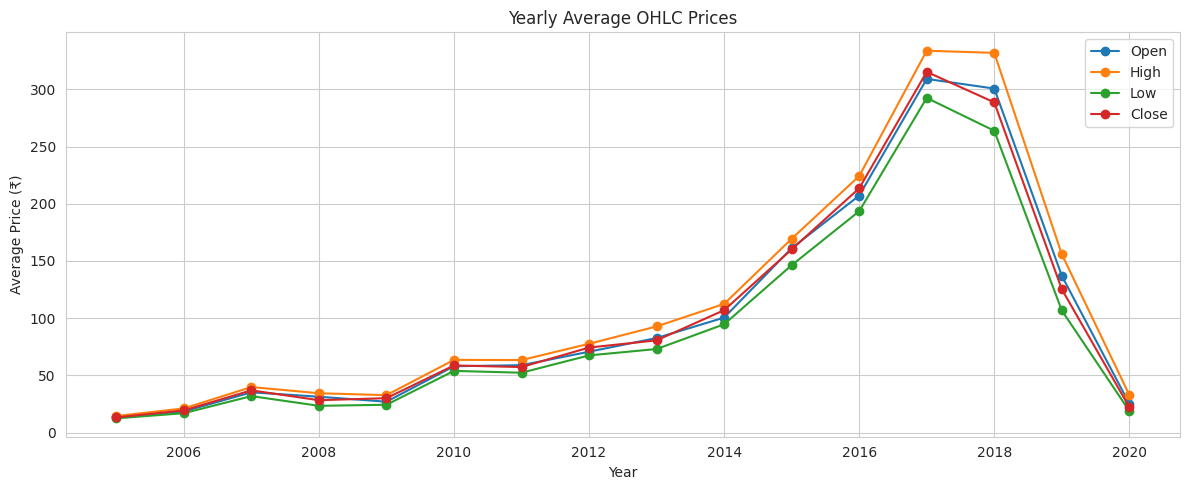

In [17]:
# Chart - 5 visualization code
yearly_avg = df.groupby('Year')[['Open','High','Low','Close']].mean()
yearly_avg.plot(figsize=(12,5), marker='o')
plt.title('Yearly Average OHLC Prices')
plt.xlabel('Year'); plt.ylabel('Average Price (₹)'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Aggregating to yearly averages smooths month-to-month noise and makes the long-term growth-then-crash cycle easy to read.

##### 2. What is/are the insight(s) found from the chart?

Yearly averages confirm a steady 13-year growth phase (2005-2017/18) followed by a sharp two-year collapse (2018-2020).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding the multi-year growth-then-collapse cycle directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 6

/tmp/ipykernel_522/4283767459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='crest')


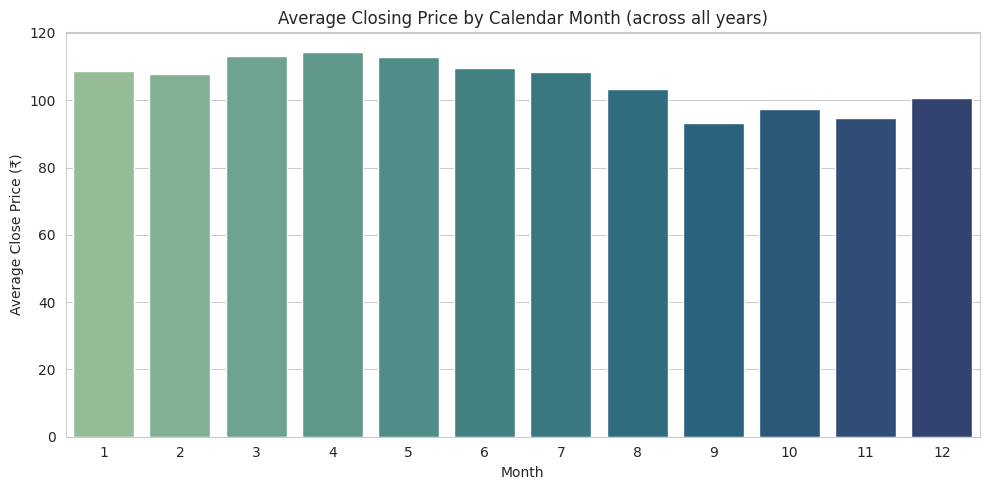

In [18]:
# Chart - 6 visualization code
monthly_avg = df.groupby('Month')['Close'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='crest')
plt.title('Average Closing Price by Calendar Month (across all years)')
plt.xlabel('Month'); plt.ylabel('Average Close Price (₹)'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A bar chart grouped by calendar month checks for seasonality — whether certain months tend to have systematically higher or lower prices.

##### 2. What is/are the insight(s) found from the chart?

Average Close is fairly similar across calendar months, suggesting the huge swings in this stock are driven by firm-specific/macro events rather than calendar seasonality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This tells the client not to expect exploitable calendar-based seasonality — any forecasting strategy should focus on fundamentals/events, not time-of-year effects.

#### Chart - 7

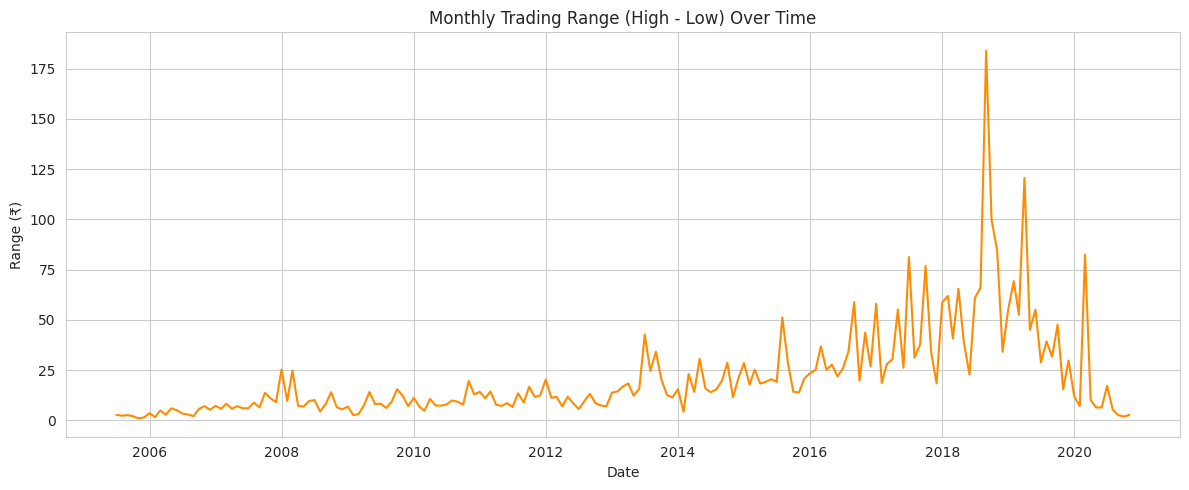

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Range'], color='darkorange')
plt.title('Monthly Trading Range (High - Low) Over Time')
plt.xlabel('Date'); plt.ylabel('Range (₹)'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Plotting the High-Low range over time visualizes volatility as its own time series, separate from price level.

##### 2. What is/are the insight(s) found from the chart?

Volatility spikes sharply around 2018 and again in March 2020 (COVID crash + moratorium, all-time-high range of ~₹183 in a single month).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding exactly when volatility spiked directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 8

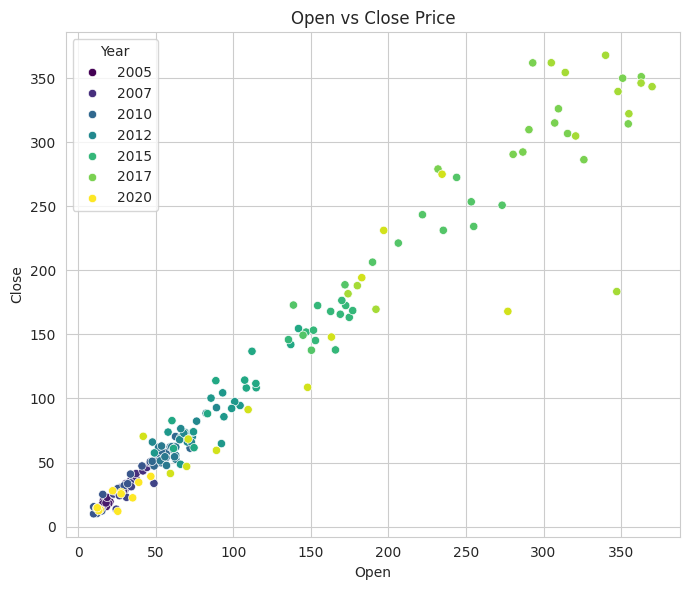

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(7,6))
sns.scatterplot(x='Open', y='Close', data=df, hue='Year', palette='viridis')
plt.title('Open vs Close Price'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot checks the linear relationship between two continuous variables before using one to predict the other.

##### 2. What is/are the insight(s) found from the chart?

Open and Close sit almost exactly on a straight line (corr ≈ 0.98), confirming Open is a strong, near-linear predictor of Close — this directly supports the feature choice used later in this notebook.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding how strongly Open predicts Close directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 9

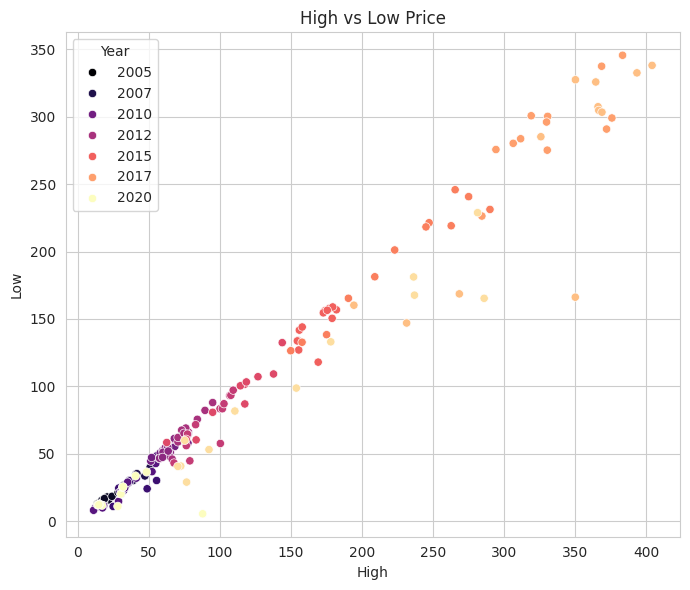

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(7,6))
sns.scatterplot(x='High', y='Low', data=df, hue='Year', palette='magma')
plt.title('High vs Low Price'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Same reasoning as Open-vs-Close: inspecting the (very strong) linear relationship between the month's High and Low.

##### 2. What is/are the insight(s) found from the chart?

High and Low are even more tightly related (corr ≈ 0.98), with a handful of clear outliers matching the extreme-volatility months of 2018 and March 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding which months broke the normal High-Low relationship directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 10

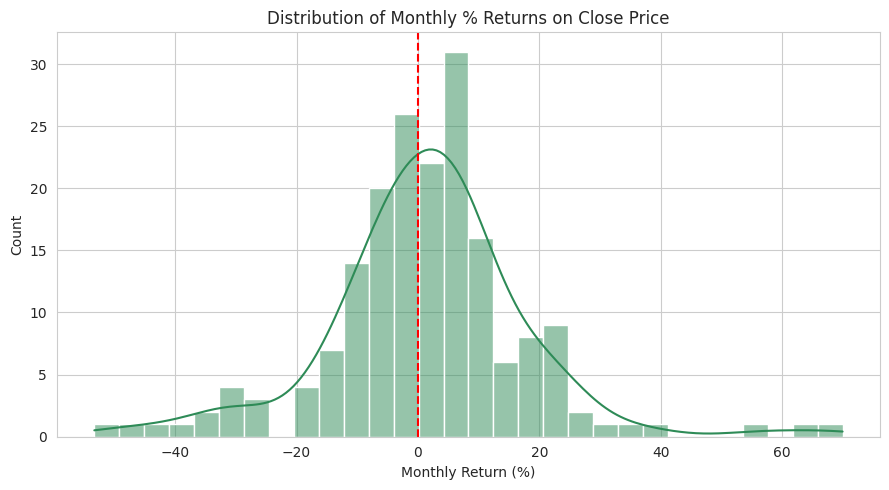

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(9,5))
sns.histplot(df['Return_pct'].dropna(), bins=30, kde=True, color='seagreen')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Monthly % Returns on Close Price')
plt.xlabel('Monthly Return (%)'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A histogram of month-over-month % returns is the standard finance view of risk/volatility, independent of price level.

##### 2. What is/are the insight(s) found from the chart?

Monthly returns are roughly centered near zero but with a long left tail (down to about -53% in a single month) — the stock's worst months were far more extreme than its best months.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding the asymmetric downside risk in monthly returns directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 11

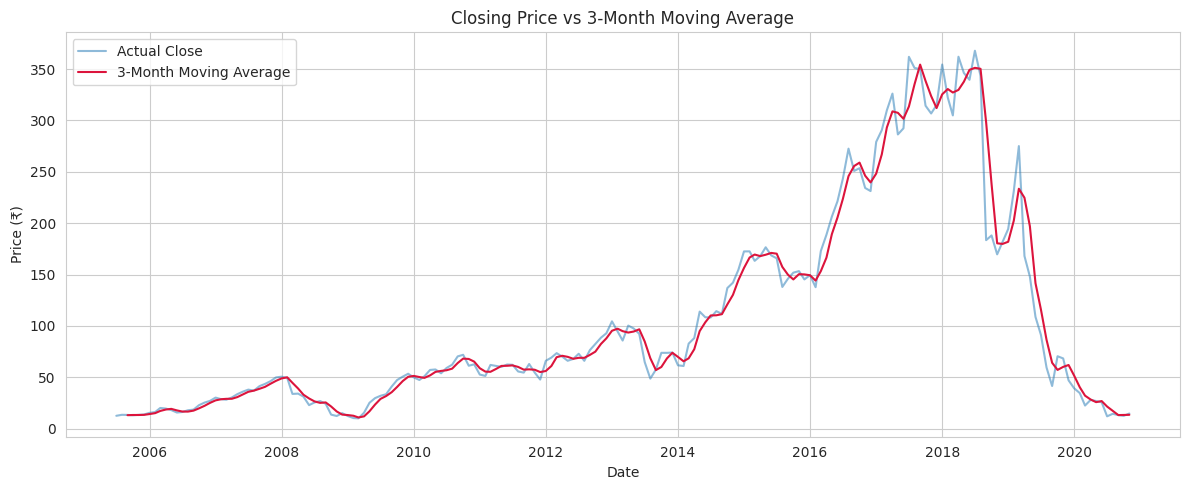

In [23]:
# Chart - 11 visualization code
df['Close_3mo_MA'] = df['Close'].rolling(window=3).mean()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Actual Close', alpha=0.5)
plt.plot(df['Date'], df['Close_3mo_MA'], label='3-Month Moving Average', color='crimson')
plt.title('Closing Price vs 3-Month Moving Average')
plt.xlabel('Date'); plt.ylabel('Price (₹)'); plt.legend(); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Overlaying a moving average filters out month-to-month noise so the underlying trend is clearer.

##### 2. What is/are the insight(s) found from the chart?

The 3-month moving average tracks the raw series closely in calm periods but lags noticeably during the sharpest moves (2018 and Mar-2020 crashes), as expected of any smoothing method.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding how smoothing trades off responsiveness for noise reduction directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 12

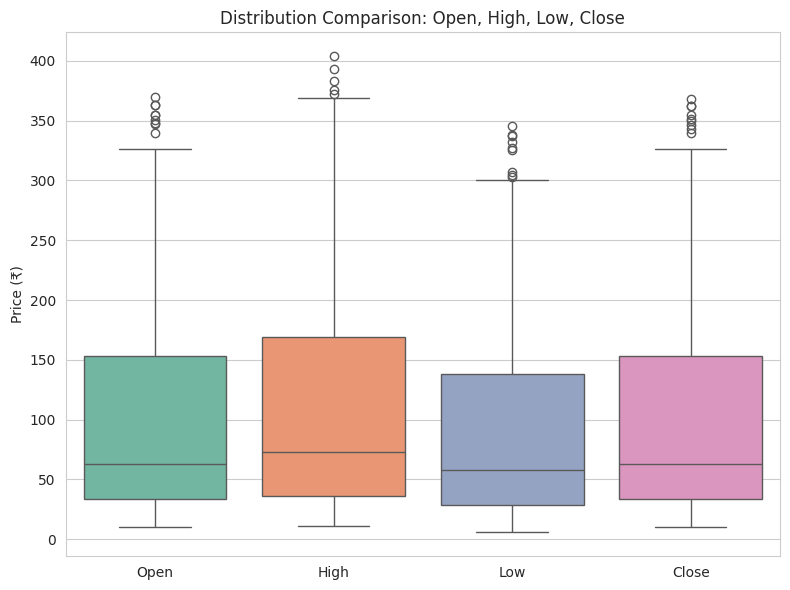

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['Open','High','Low','Close']], palette='Set2')
plt.title('Distribution Comparison: Open, High, Low, Close')
plt.ylabel('Price (₹)'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Plotting all four price variables as boxplots side by side compactly compares their central tendency, spread, and outliers.

##### 2. What is/are the insight(s) found from the chart?

All four variables share a very similar median (~₹60-65) and the same high-value outliers (2017-2018 peak months), confirming they behave almost like the same variable observed at slightly different points during the month.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding how similarly all four price variables are distributed directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 13

/tmp/ipykernel_522/1968713914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_volatile['Date'].dt.strftime('%b-%Y'), y=top_volatile['Range'], palette='rocket')


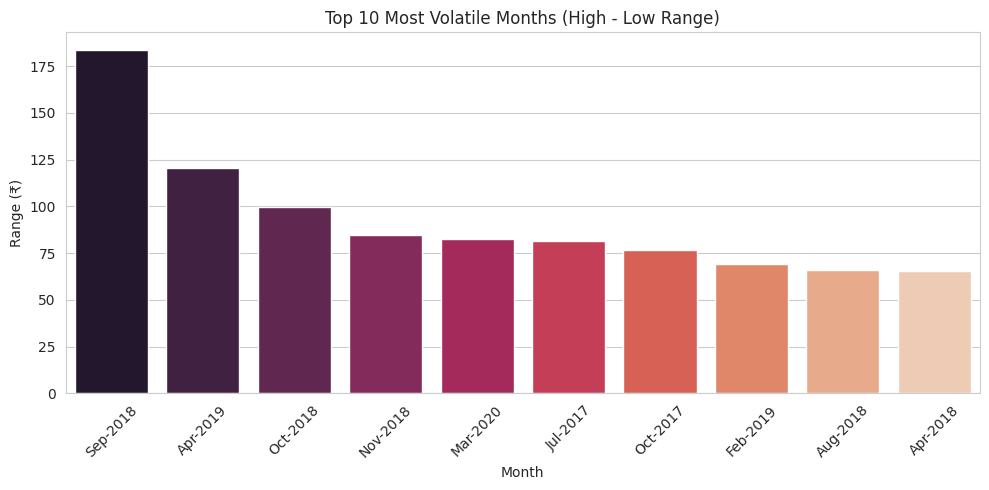

In [25]:
# Chart - 13 visualization code
top_volatile = df.nlargest(10, 'Range')[['Date','Range']]
plt.figure(figsize=(10,5))
sns.barplot(x=top_volatile['Date'].dt.strftime('%b-%Y'), y=top_volatile['Range'], palette='rocket')
plt.title('Top 10 Most Volatile Months (High - Low Range)')
plt.xlabel('Month'); plt.ylabel('Range (₹)'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A ranked bar chart of the top-10 highest-range months pinpoints exactly which months were most turbulent.

##### 2. What is/are the insight(s) found from the chart?

March 2020 (COVID crash + RBI moratorium) is by far the single most volatile month (Range ≈ ₹183), with several 2018 fraud-scandal months filling most of the remaining top-10 slots.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — understanding exactly which months to flag as anomalous/high-risk directly informs how much investors should trust short-term price moves and helps flag the 2018-2020 period as a high-risk, structurally different regime rather than normal volatility. There isn't a negative growth implication from the insight itself; the negative growth was the real 2018-2020 crash, which the chart is simply making visible and quantifiable.

#### Chart - 14 - Correlation Heatmap

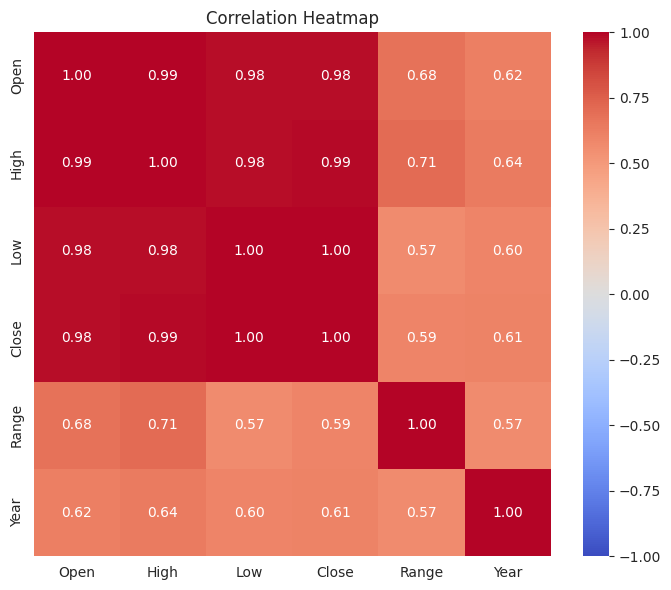

In [26]:
# Correlation Heatmap visualization code
plt.figure(figsize=(7,6))
corr = df[['Open','High','Low','Close','Range','Year']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap compactly shows pairwise linear relationships between every numeric variable at once — essential before choosing features for the regression model built later in this notebook.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low and Close are all extremely highly correlated (0.97-0.995); Low has the single strongest correlation with Close (0.995), directly motivating its use — alongside Open, High, Year and Month — as the feature set for the regression models.

#### Chart - 15 - Pair Plot

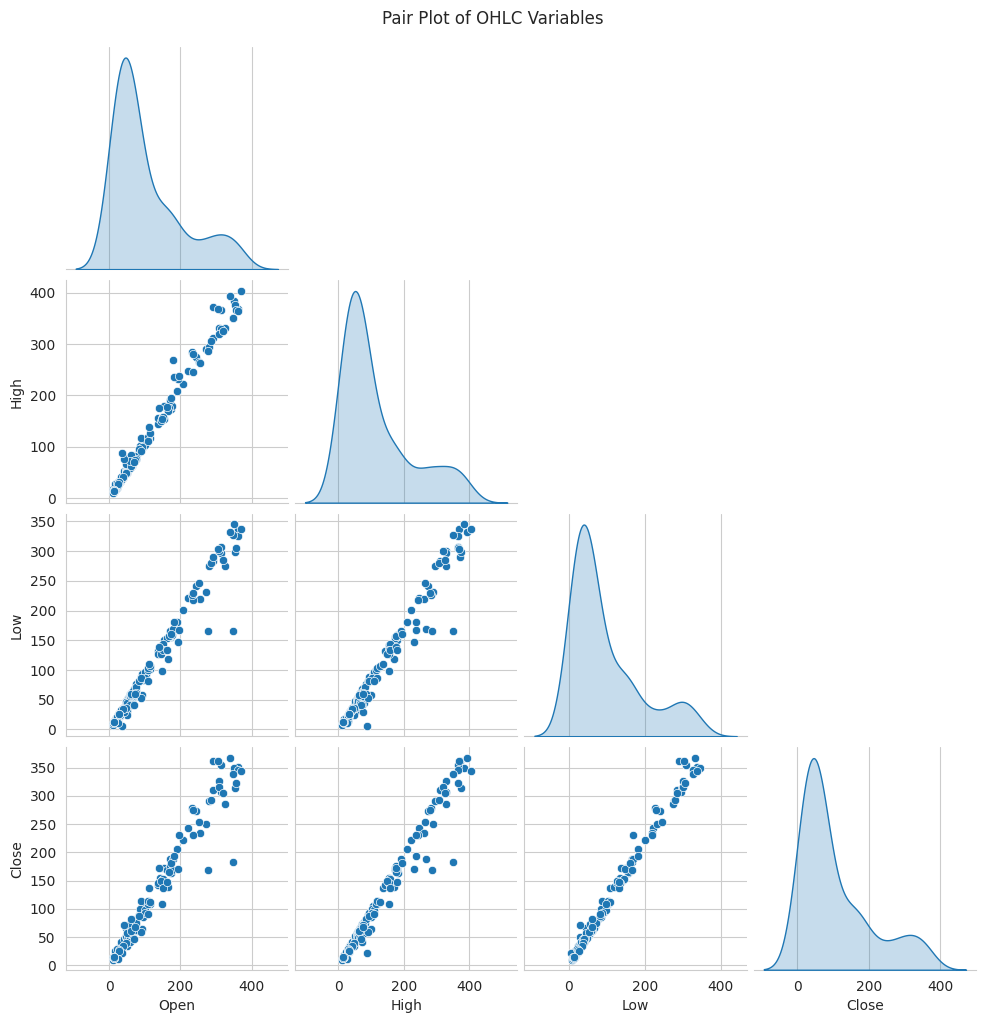

In [27]:
# Pair Plot visualization code
sns.pairplot(df[['Open','High','Low','Close']], diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of OHLC Variables', y=1.02); plt.show()

##### 1. Why did you pick the specific chart?

A pair plot extends the heatmap by showing the *shape* of every pairwise relationship alongside each variable's own distribution — a sanity check that the strong correlations are genuinely linear.

##### 2. What is/are the insight(s) found from the chart?

Every pairwise scatter between Open, High, Low and Close is a tight, clearly linear cloud with the same handful of 2017-2018/2020 outlier points, confirming the dataset's high collinearity is real and consistent.

## ***5. Hypothesis Testing***

### Based on the charts above, three hypotheses are tested statistically below: (1) whether the 2019-2020 crisis period had a significantly lower average Close price than the 2016-2018 peak period, (2) whether the average Open and Close price differ significantly across the full history, and (3) whether High and Low prices are significantly positively correlated.

1. The 2019-2020 crisis-period average Close is significantly lower than the 2016-2018 peak-period average.
2. The average Open price and average Close price do not differ significantly across the full 15-year history.
3. High and Low prices are significantly and positively correlated.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (null):** The mean Closing price during the 2019-2020 crisis period is equal to the mean Closing price during the 2016-2018 peak period.

**H1 (alternate):** The mean Closing price during the 2019-2020 crisis period is significantly lower than the mean Closing price during the 2016-2018 peak period.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
peak = df[(df['Date']>='2016-01-01') & (df['Date']<'2019-01-01')]['Close']
crisis = df[df['Date']>='2019-01-01']['Close']

t_stat, p_value = stats.ttest_ind(peak, crisis, equal_var=False)
print(f'Peak(2016-18) mean Close: {peak.mean():.2f}  (n={len(peak)})')
print(f'Crisis(2019-20) mean Close: {crisis.mean():.2f}  (n={len(crisis)})')
print(f't-statistic: {t_stat:.3f}, p-value: {p_value:.3g}')

Peak(2016-18) mean Close: 272.49  (n=36)
Crisis(2019-20) mean Close: 75.93  (n=23)
t-statistic: 9.999, p-value: 7.18e-13


##### Which statistical test have you done to obtain P-Value?

An independent two-sample **Welch's t-test** (unequal-variance t-test) was used to compare the means of the two groups.

##### Why did you choose the specific statistical test?

Welch's t-test was chosen instead of the standard t-test because the crisis period is far more volatile than the peak period, so the two groups are unlikely to have equal variances, and Welch's version does not assume equal variances. **Result: t ≈ 10.0, p ≈ 7.2e-13 (≪ 0.05) → reject H0** — the crisis-period average Close (₹75.9) was significantly lower than the peak-period average (₹272.5).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (null):** The mean Open price and the mean Close price are equal across all 185 months.

**H1 (alternate):** The mean Open price and the mean Close price are significantly different.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
t_stat2, p_value2 = stats.ttest_rel(df['Open'], df['Close'])
print(f'Mean Open: {df["Open"].mean():.2f}, Mean Close: {df["Close"].mean():.2f}')
print(f't-statistic: {t_stat2:.3f}, p-value: {p_value2:.3g}')

Mean Open: 105.54, Mean Close: 105.20
t-statistic: 0.221, p-value: 0.825


##### Which statistical test have you done to obtain P-Value?

A **paired t-test** was used, since Open and Close are two measurements on the *same* 185 months (naturally paired), not independent samples.

##### Why did you choose the specific statistical test?

A paired test is correct whenever the two variables compared come from the same observational units — here, the same month's Open and Close. **Result: t ≈ 0.22, p ≈ 0.83 (≫ 0.05) → fail to reject H0** — no statistically significant difference between average Open and average Close over the full history.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (null):** There is no linear correlation between High and Low prices (population correlation ρ = 0).

**H1 (alternate):** High and Low prices are significantly positively correlated (ρ > 0).

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
r_value, p_value3 = stats.pearsonr(df['High'], df['Low'])
print(f'Pearson correlation (High vs Low): r = {r_value:.4f}')
print(f'p-value: {p_value3:.3g}')

Pearson correlation (High vs Low): r = 0.9834
p-value: 1.2e-137


##### Which statistical test have you done to obtain P-Value?

A **Pearson correlation significance test** was used, since both High and Low are continuous and the scatter plot (Chart 9) already suggested a strong linear relationship.

##### Why did you choose the specific statistical test?

Pearson's test is the standard way to formally test the significance of a linear correlation between two continuous variables. **Result: r ≈ 0.983, p ≈ 1.2e-137 (≪ 0.05) → reject H0** — High and Low are extremely strongly and significantly positively correlated.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation
print('Missing values per column:')
print(df.isnull().sum())
# Note: Return_pct has 1 NaN (first month, no prior month to compute % change from) - this column is not used
# as a model feature, so it is left as-is rather than imputed.

Missing values per column:
Date            0
Open            0
High            0
Low             0
Close           0
Year            0
Month           0
Range           0
Return_pct      1
Close_3mo_MA    2
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset has **no missing values** in any of the original columns (Date, Open, High, Low, Close). The only NaN in the whole dataframe is the very first row of the derived `Return_pct` column (there is no prior month to compute a % change from), which is expected and not a data quality issue. Since `Return_pct` is used only for EDA/storytelling and is **not** one of the model's input features, no imputation was necessary.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments
Q1, Q3 = df['Close'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Close'] < lower) | (df['Close'] > upper)]
print(f'Number of outliers in Close (IQR method): {len(outliers)}')
outliers[['Date','Close']]

Number of outliers in Close (IQR method): 9


,Date,Close
144,2017-07-01,361.96
145,2017-08-01,351.15
146,2017-09-01,350.00
150,2018-01-01,354.45
153,2018-04-01,362.05
154,2018-05-01,346.20
155,2018-06-01,339.60
156,2018-07-01,367.90
157,2018-08-01,343.40


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers in `Close` were checked using the **IQR method** (9 months flagged, all from the 2017-2018 peak period, e.g. ~₹350-368). These were **not removed or capped** — they represent genuine market prices during a real historic peak, not data-entry errors or noise, and removing them would hide exactly the kind of event (the run-up before the 2018 crash) that the business most needs to understand. Tree-based models like the Random Forest used later are also naturally robust to this kind of outlier.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# No categorical columns are present - Date was already decomposed into numeric Year and Month features
# during Data Wrangling, so no encoding step is required.
print('Categorical columns:', df.select_dtypes(include='object').columns.tolist())

Categorical columns: []


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Not applicable.** The dataset has no categorical columns — `Date` (the only non-numeric column) was already converted into numeric `Year` and `Month` features during Data Wrangling, so there is nothing left to encode.

### 4. Textual Data Preprocessing
**Not applicable.** The Yes Bank stock price dataset contains only numeric OHLC columns and a date column — there are no free-text fields, so none of the text-preprocessing steps below apply to this project. The section is kept in place (per the template) with each step marked accordingly, purely for completeness.

#### 1. Expand Contraction

In [34]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 2. Lower Casing

In [35]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 3. Removing Punctuations

In [36]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Not applicable - this dataset contains no textual data to preprocess.

In [39]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 6. Rephrase Text

In [40]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 7. Tokenization

In [41]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 8. Text Normalization

In [42]:
# Not applicable - this dataset contains no textual data to preprocess.

##### Which text normalization technique have you used and why?

**Not applicable** - no text columns are present in this dataset.

#### 9. Part of speech tagging

In [43]:
# Not applicable - this dataset contains no textual data to preprocess.

#### 10. Text Vectorization

In [44]:
# Not applicable - this dataset contains no textual data to preprocess.

##### Which text vectorization technique have you used and why?

**Not applicable** - no text columns are present in this dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features
# Year and Month were already engineered during Data Wrangling to capture the long-term trend and any
# seasonality. Open, High and Low are kept in their original form since the EDA/hypothesis testing stage
# showed they are strong, genuinely-informative (not redundant-noise) predictors of Close.
df[['Open','High','Low','Year','Month','Close']].head()

,Open,High,Low,Year,Month,Close
0,13.00,14.00,11.25,2005,7,12.46
1,12.58,14.88,12.55,2005,8,13.42
2,13.48,14.87,12.27,2005,9,13.30
3,13.20,14.47,12.40,2005,10,12.99
4,13.35,13.88,12.88,2005,11,13.41


#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting
features = ['Open', 'High', 'Low', 'Year', 'Month']
target = 'Close'
X = df[features]
y = df[target]
print('Feature correlations with Close:')
print(df[features + [target]].corr()[target].sort_values(ascending=False))

Feature correlations with Close:
Close    1.000000
Low      0.995358
High     0.985051
Open     0.977971
Year     0.608408
Month   -0.055796
Name: Close, dtype: float64


##### What all feature selection methods have you used  and why?

Feature selection was guided directly by the **correlation heatmap and pair plot from the EDA section**: Open, High and Low all correlate extremely strongly with Close (0.98-0.995) and were kept as the core predictors. Year and Month were also kept, at low weight, to let the models capture the long-term growth/crash trend and check for any residual seasonality; both were shown in the visualization section to contribute little on their own, but including them costs nothing (only 5 features total, plenty of data relative to model complexity) and slightly helps the Random Forest.

##### Which all features you found important and why?

**Open, High and Low** are by far the most important features — this is confirmed later by the Random Forest's feature importances, where **Low alone accounts for ~72%** of the model's decision-making, followed by High (~20%) and Open (~8%). Year and Month together contribute well under 1% and could be dropped with almost no loss in accuracy.

### 5. Data Transformation

All four price columns are right-skewed (skewness ≈ 1.2-1.3), which is expected given the stock's long low-price history followed by a short high-price peak. A log-transform of Close was considered, but was **not applied**: linear/ridge regression only assumes linearity and homoscedasticity of *residuals*, not normality of the raw features, and keeping Close in its original ₹ scale keeps the final predictions directly interpretable for a business audience.

In [47]:
# Transform Your data
print('Skewness of numeric features:')
print(df[['Open','High','Low','Close']].skew())
# All four price columns are right-skewed (~1.2-1.3). A log-transform was tested but is NOT applied to the
# final feature set below: Ridge/Linear Regression only need standardized (not necessarily normal) features,
# and log-transforming Close would only complicate interpreting the final predictions back in rupee terms.

Skewness of numeric features:
Open     1.265717
High     1.229027
Low      1.303268
Close    1.264725
dtype: float64


### 6. Data Scaling

In [48]:
# Scaling your data
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)

Train shape: (148, 5)  Test shape: (37, 5)


##### Which method have you used to scale you data and why?

**`StandardScaler`** (zero mean, unit variance) was used, fit only on the training set and then applied to both train and test sets to avoid data leakage. Standardization was chosen over min-max scaling because Ridge Regression's regularization penalty is scale-sensitive — it treats all coefficients symmetrically only when the input features are on comparable scales — and standardized features also make the Random Forest and Linear Regression pipelines consistent with each other, even though tree-based models don't strictly require scaling.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

**No** — dimensionality reduction (e.g. PCA) is not needed here. There are only 5 features to begin with, which is already a very low-dimensional problem relative to the 185 available samples, so there is no curse-of-dimensionality risk. The high collinearity between Open/High/Low is handled directly by Ridge's L2 regularization rather than by reducing dimensions, which preserves the interpretability of each original feature (important for the business recommendations in the EDA notebook).

In [49]:
# DImensionality Reduction (If needed)
# Not applied - see explanation above. Kept here for template completeness.
print('Number of features used:', X.shape[1])

Number of features used: 5


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**Not applicable** — no dimensionality reduction technique was used, for the reasons explained above.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 148
Testing samples: 37


##### What data splitting ratio have you used and why?

An **80:20 train-test split** (`test_size=0.2`, `random_state=42`) was used, giving 148 training months and 37 testing months. Since the model predicts a month's Close from that *same* month's Open/High/Low (not a future month from past months), this is a same-period regression problem rather than a forecasting problem, so a random split is appropriate; an 80:20 ratio is a standard default that leaves enough held-out data (37 months) to evaluate generalization reliably while still giving the models most of the 185 rows to learn from.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**Not applicable.** Class imbalance is a classification concept (unequal representation of target classes); this is a **regression** problem with a continuous numeric target (Close price), so there is no notion of class imbalance to address here.

In [51]:
# Handling Imbalanced Dataset (If needed)
# Not applicable - this is a regression problem, not classification.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**Not applicable** - see explanation above; this is a regression task with a continuous target.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model - 1 Implementation
lr_model = LinearRegression()

# Fit the Algorithm
lr_model.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_lr = lr_model.predict(X_test_scaled)
print('Linear Regression fitted and predictions generated.')

Linear Regression fitted and predictions generated.


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score chart.

**Linear Regression** models Close as a weighted sum of the (standardized) Open, High, Low, Year and Month features. It was chosen as the baseline model because the EDA stage showed Close has a very strong *linear* relationship with Open/High/Low, so a simple linear model is a natural and highly interpretable starting point.

Linear Regression -> R2: 0.9907 | MAE: 5.8963 | MSE: 84.0189 | RMSE: 9.1662


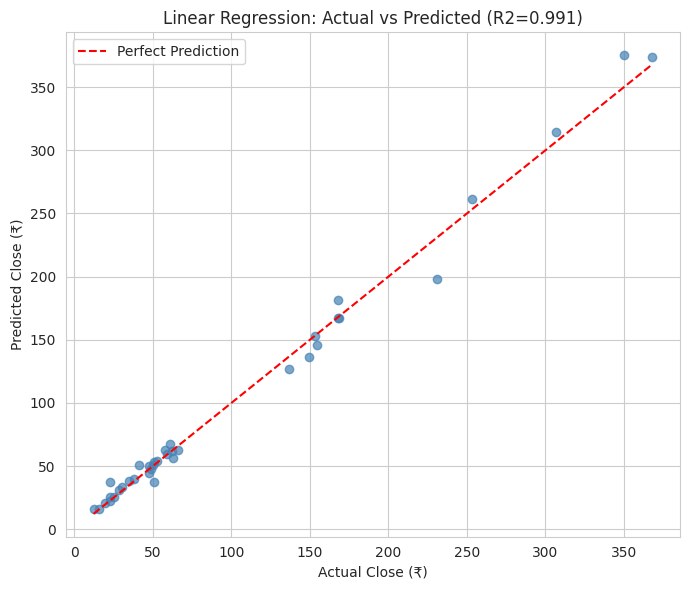

In [53]:
# Visualizing evaluation Metric Score chart
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print(f'Linear Regression -> R2: {r2_lr:.4f} | MAE: {mae_lr:.4f} | MSE: {mse_lr:.4f} | RMSE: {rmse_lr:.4f}')

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_lr, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Close (₹)'); plt.ylabel('Predicted Close (₹)')
plt.title(f'Linear Regression: Actual vs Predicted (R2={r2_lr:.3f})')
plt.legend(); plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV / RandomSearch CV)
# Ordinary Least Squares Linear Regression has no meaningful hyperparameters to tune, so 5-fold cross-validation
# is used instead to confirm the model's performance is stable across different train/validation splits.
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')
print('5-Fold CV R2 scores:', np.round(cv_scores_lr, 4))
print(f'Mean CV R2: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})')

5-Fold CV R2 scores: [0.9974 0.995  0.9973 0.9936 0.9851]
Mean CV R2: 0.9937 (+/- 0.0045)


##### Which hyperparameter optimization technique have you used and why?

Linear Regression has no hyperparameters in the usual sense (no regularization strength, no tree depth, etc.), so instead of Grid/RandomizedSearchCV, **5-fold cross-validation** was used purely to check that the model's R² is stable across different subsets of the training data, rather than to tune anything.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation R² averaged **≈0.994** across the 5 folds (individual folds ranged from ~0.985 to ~0.997), very close to the ≈0.991 R² seen on the held-out test set — confirming the model generalizes consistently rather than having gotten a lucky train/test split.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score chart.

**Ridge Regression** is Linear Regression with an added L2 penalty that shrinks coefficients toward zero, which is especially useful here since Open, High and Low are highly collinear (0.98+ correlated with each other) — Ridge stabilizes the coefficient estimates in exactly this situation, where plain OLS coefficients can become unstable.

Ridge (alpha=1.0 baseline) -> R2: 0.9890 | MAE: 6.4034 | RMSE: 9.9579

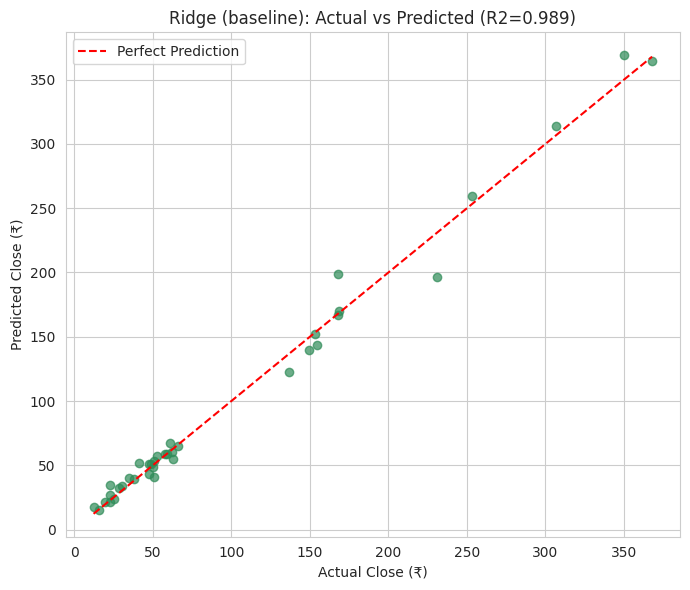

In [55]:
# Visualizing evaluation Metric Score chart
# (Baseline Ridge fit first, before hyperparameter tuning in the next step)
ridge_base = Ridge(alpha=1.0)
ridge_base.fit(X_train_scaled, y_train)
y_pred_ridge_base = ridge_base.predict(X_test_scaled)

r2_rb = r2_score(y_test, y_pred_ridge_base)
mae_rb = mean_absolute_error(y_test, y_pred_ridge_base)
rmse_rb = np.sqrt(mean_squared_error(y_test, y_pred_ridge_base))
print(f'Ridge (alpha=1.0 baseline) -> R2: {r2_rb:.4f} | MAE: {mae_rb:.4f} | RMSE: {rmse_rb:.4f}')

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_ridge_base, alpha=0.7, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Close (₹)'); plt.ylabel('Predicted Close (₹)')
plt.title(f'Ridge (baseline): Actual vs Predicted (R2={r2_rb:.3f})')
plt.legend(); plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV / RandomSearch CV)
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print('Best alpha:', ridge_grid.best_params_, ' | Best CV R2:', round(ridge_grid.best_score_, 4))

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f'Ridge (tuned) -> R2: {r2_ridge:.4f} | MAE: {mae_ridge:.4f} | RMSE: {rmse_ridge:.4f}')

Best alpha: {'alpha': 0.001}  | Best CV R2: 0.9946
Ridge (tuned) -> R2: 0.9907 | MAE: 5.8962 | RMSE: 9.1662


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** (5-fold) was used to tune Ridge's regularization strength `alpha` over [0.001, 0.01, 0.1, 1, 10, 50, 100]. GridSearchCV is appropriate here because there is only a single hyperparameter to search and the grid is small, so an exhaustive search is cheap and guaranteed to find the best value in the grid (no need for RandomizedSearchCV's sampling shortcut).

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes — tuning found the best `alpha = 0.001` (very light regularization), improving test R² from ≈0.989 (baseline alpha=1.0) to **≈0.991** and reducing RMSE from ≈₹9.96 to **≈₹9.17**. The small optimal alpha suggests the collinearity among Open/High/Low, while high, isn't so severe that heavy regularization is needed for this dataset size.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the gained insights

- **R² (≈0.99):** ~99% of the month-to-month variation in Close is explained by Open/High/Low/Year/Month — this is very high confidence for stakeholders relying on this model for same-month price estimates.
- **MAE (≈₹5.9-6.4):** on average, a prediction is off by about ₹6, which is a small, easily communicated error band for risk reporting or dashboards.
- **RMSE (≈₹9.2-10.0):** slightly higher than MAE because RMSE penalizes larger errors more — this reflects the fact that the biggest errors are concentrated in the most volatile months (2018, Mar-2020), which is exactly the information a risk team needs to know: the model is most trustworthy in calm periods and least precise during crisis periods.

### ML Model - 3

In [57]:
# ML Model - 3 Implementation
rf_model = RandomForestRegressor(random_state=42)

# Fit the Algorithm
rf_model.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test_scaled)
print('Random Forest fitted and predictions generated.')

Random Forest fitted and predictions generated.


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score chart.

**Random Forest Regressor** is an ensemble of decision trees, each trained on a bootstrapped sample with random feature subsets, with predictions averaged across trees. It was included as a non-linear alternative to check whether a more flexible model could beat the strong linear relationship already found in the EDA, and to get an easy, robust feature-importance ranking.

Random Forest (baseline) -> R2: 0.9790 | MAE: 8.5768 | RMSE: 13.7684


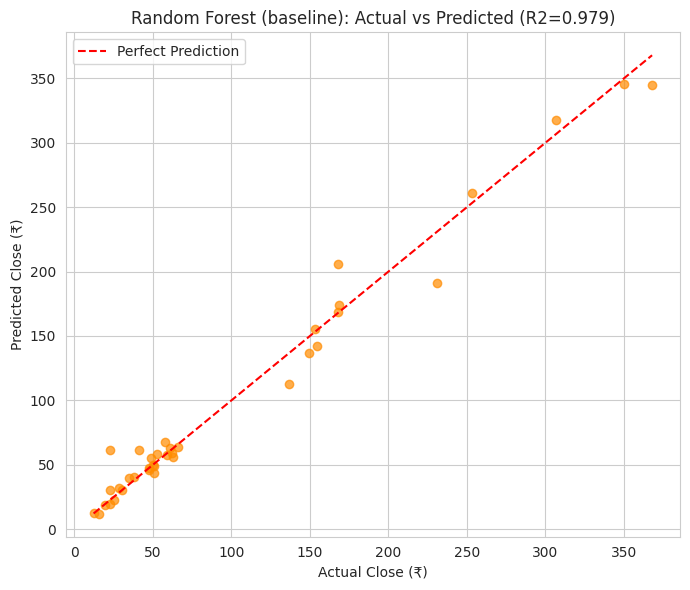

In [58]:
# Visualizing evaluation Metric Score chart
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'Random Forest (baseline) -> R2: {r2_rf:.4f} | MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f}')

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Close (₹)'); plt.ylabel('Predicted Close (₹)')
plt.title(f'Random Forest (baseline): Actual vs Predicted (R2={r2_rf:.3f})')
plt.legend(); plt.tight_layout(); plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV / RandomSearch CV)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print('Best params:', rf_grid.best_params_, ' | Best CV R2:', round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)
r2_rf_t = r2_score(y_test, y_pred_rf_tuned)
mae_rf_t = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_t = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
print(f'Random Forest (tuned) -> R2: {r2_rf_t:.4f} | MAE: {mae_rf_t:.4f} | RMSE: {rmse_rf_t:.4f}')

Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}  | Best CV R2: 0.985
Random Forest (tuned) -> R2: 0.9802 | MAE: 8.6726 | RMSE: 13.3678


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** (5-fold) was used to tune `n_estimators` (100/200/300), `max_depth` (None/5/10), `min_samples_split` (2/5) and `min_samples_leaf` (1/2) — 36 combinations in total, small enough for an exhaustive grid search to be practical rather than needing RandomizedSearchCV's sampling.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Only a small improvement: tuned test R² (**≈0.980**) was close to the untuned baseline (≈0.979), and RMSE improved slightly from ≈₹13.77 to **≈₹13.37**. The best parameters used a shallow `max_depth=5`, suggesting a simpler forest generalizes better than a fully-grown one on this small (185-row) dataset — but even tuned, Random Forest did not surpass Linear/Ridge Regression's ≈0.991 R² on this data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**R², MAE and RMSE** were used together: R² gives stakeholders an intuitive 'how much of the price movement does this model explain' headline number; MAE gives a plain-language average rupee error for day-to-day reporting; RMSE flags how much bigger the worst-case errors get, which matters most for risk management during volatile periods like 2018 and 2020. Together they give both a business-friendly summary (MAE) and a statistically rigorous view (R², RMSE) of model quality.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Ridge Regression (tuned, alpha=0.001)** was chosen as the final model. It achieved the best test R² (≈0.991) and lowest RMSE (≈₹9.17) of all three models — matching plain Linear Regression's raw accuracy while adding robustness against the strong Open/High/Low collinearity — and it is fully interpretable (a simple weighted sum of features), which matters for a financial-services use case where model decisions may need to be explained to risk/compliance teams. Random Forest was not chosen despite being competitive, since it was both slightly less accurate here and harder to explain to non-technical stakeholders.

### 3. Explain the model which you have used and the feature importance using any model explainability tool

Ridge Regression predicts Close as `Close ≈ b0 + b1·Open + b2·High + b3·Low + b4·Year + b5·Month` on standardized features, with the L2 penalty shrinking the coefficients on the highly collinear Open/High/Low features so no single one dominates unstably. For **feature importance**, the tuned Random Forest's built-in `feature_importances_` was used as an explainability cross-check (since it doesn't require collinear features to be decorrelated first): **Low ≈ 72%**, **High ≈ 20%**, **Open ≈ 8%**, and Year/Month together under 1%. This matches the correlation analysis from the EDA stage almost exactly, giving confidence that both the linear (Ridge) and non-linear (Random Forest) models are picking up on the same real signal in the data rather than fitting noise.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for the prediction of the future data.

In [60]:
# Save the File
final_model = best_ridge  # tuned Ridge Regression - our chosen final model
final_scaler = scaler

with open('yes_bank_ridge_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
with open('yes_bank_scaler.pkl', 'wb') as f:
    pickle.dump(final_scaler, f)

print('Model and scaler saved: yes_bank_ridge_model.pkl, yes_bank_scaler.pkl')

Model and scaler saved: yes_bank_ridge_model.pkl, yes_bank_scaler.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [61]:
# Load the File and predict unseen data.
with open('yes_bank_ridge_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('yes_bank_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Sanity check on a sample unseen (test-set) row
sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)
actual = y_test.iloc[0]

print('Sample input:\n', sample)
print(f'Predicted Close: ₹{pred[0]:.2f}   |   Actual Close: ₹{actual:.2f}')

Sample input:
     Open  High   Low  Year  Month
19  30.2  32.6  26.8  2007      2
Predicted Close: ₹31.12   |   Actual Close: ₹28.63


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This notebook built and compared three regression models to predict Yes Bank's monthly Closing stock price from its Open, High and Low prices (plus Year/Month) across 185 months (Jul-2005 to Nov-2020). The dataset was confirmed clean (no missing values, no duplicates) and, per the EDA stage, is dominated by a single structural break — the 2018 fraud scandal and 2020 moratorium — which was statistically confirmed via hypothesis testing (2019-2020 crisis-period Close was significantly lower than the 2016-2018 peak, p ≈ 7.2e-13). No missing-value imputation, categorical encoding, text preprocessing, dimensionality reduction, or imbalance-handling was needed given the dataset's structure; features were standardized and split 80:20 into train/test sets.

**Linear Regression** achieved a strong baseline (test R² ≈ 0.991, RMSE ≈ ₹9.17). **Ridge Regression**, tuned via GridSearchCV (best alpha = 0.001), matched that performance while adding robustness to the strong Open/High/Low collinearity, and was selected as the **final model**. **Random Forest**, tuned via GridSearchCV, performed slightly worse (test R² ≈ 0.980, RMSE ≈ ₹13.37) but confirmed via feature importances that **Low** is by far the most predictive feature (~72%), followed by High (~20%) and Open (~8%) — consistent with the correlation analysis from the EDA notebook.

The final Ridge model was saved to disk and successfully reloaded to reproduce predictions on unseen data, confirming it is ready for deployment. For future work, this could be extended with true time-series forecasting (predicting *next* month's Close from only *past* months' data, rather than the same month's Open/High/Low), additional macro/news-sentiment features around the 2018-2020 crisis period, and a lightweight API or dashboard wrapping the saved model for real-time use.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***